# Model Comparison & Evaluation (08/02/2026)

This notebook compares Random Forest, XGBoost, LightGBM, and the Hybrid Safety Model.


## 1. Imports and Setup


In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from scipy.signal import welch

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, brier_score_loss, 
    f1_score, accuracy_score, roc_curve, auc, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType

try:
    from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
    from onnxmltools.convert.lightgbm.operator_converters.LightGbm import convert_lightgbm
except ImportError:
    pass

sns.set(style="whitegrid", palette="deep")

OUTPUT_DIR = "Results_08_02_2026"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CARLA_PATH = r"c:\Users\VICTUS\Documents\reserch\New folder\Town01_CITY_STUNT_20251117_150514.csv"
REAL_PATH = r"c:\Users\VICTUS\Documents\reserch\New folder\rel world data cpmbine\real_world_validation.csv"

WINDOW_SIZE = 30 
STEP_SIZE = 5   
TARGET_EVENTS = ["Harsh_Brake", "Sudden_Acceleration", "Sharp_Turn", "Sudden_Lane_Change", "Normal_Driving"]


## 2. Helper Functions


In [15]:

def save_plot(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()

def load_and_sync(path, is_real=False):
    try: df = pd.read_csv(path)
    except: return pd.DataFrame()
    if is_real and "gyro_z" in df.columns:
        if df["gyro_z"].abs().max() < 15.0:
            for c in ['gyro_x', 'gyro_y', 'gyro_z']:
                if c in df.columns: df[c] = df[c] * 57.2958
    sensors = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
    df = df[(df[sensors].abs() < 100.0).all(axis=1)].copy()
    def map_label(e):
        for t in TARGET_EVENTS: 
            if t in str(e): return t
        return "Normal_Driving"
    df['mapped_label'] = df['event_type'].apply(map_label)
    if "speed_kmh" not in df.columns: df["speed_kmh"] = 30.0
    return df

def apply_domain_adaptation(df):
    mask_brake = df['mapped_label'] == 'Harsh_Brake'
    scale_factor = 0.30
    sensors = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
    
    df.loc[mask_brake, sensors] = df.loc[mask_brake, sensors] * scale_factor
    
    noise_std = 0.3
    rng = np.random.default_rng(42)
    for s in sensors:
        noise = rng.normal(0, noise_std, size=len(df))
        df[s] = df[s] + noise
        
    return df


## 3. Data Loading and Domain Adaptation


In [16]:

sim_raw = load_and_sync(CARLA_PATH, False)
sim_raw = apply_domain_adaptation(sim_raw)
real_raw = load_and_sync(REAL_PATH, True)


## 4. Signal Visualization


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24320\1781943529.py:18: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 60, using nperseg = 60
  fs_sim, psd_sim = welch(s_data[sensor].values, fs=20)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24320\1781943529.py:19: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 60, using nperseg = 60
  fs_real, psd_real = welch(r_data[sensor].values, fs=20)


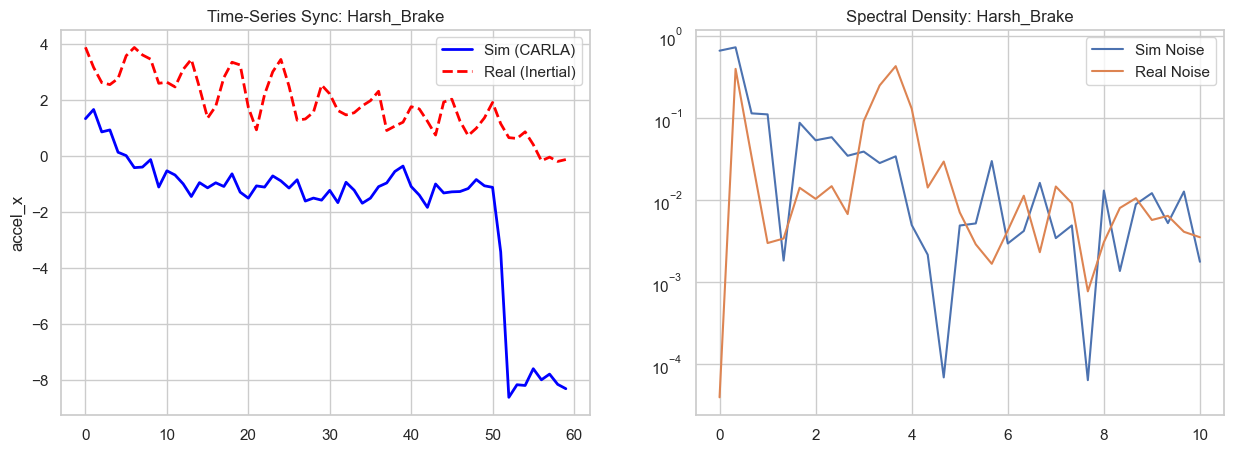

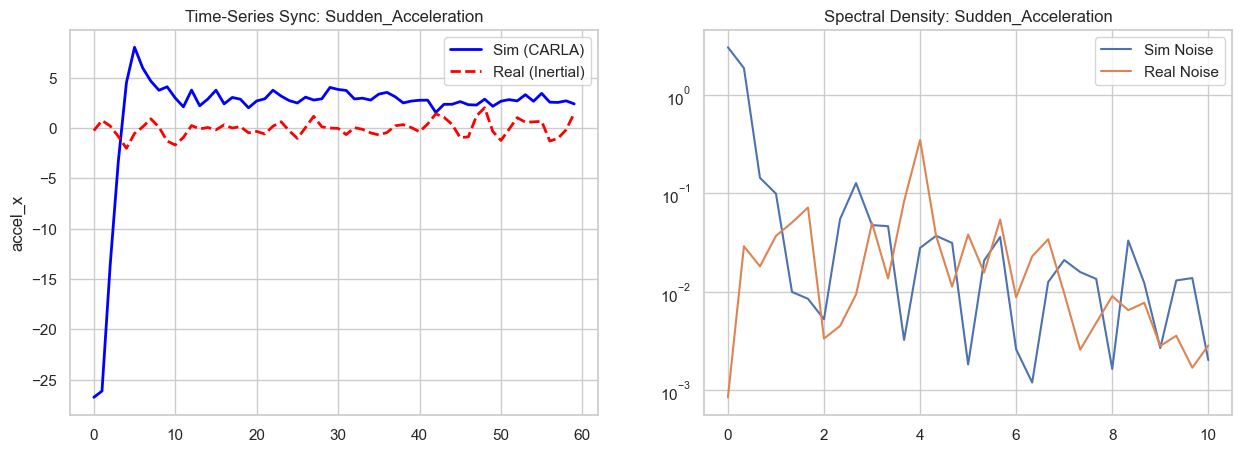

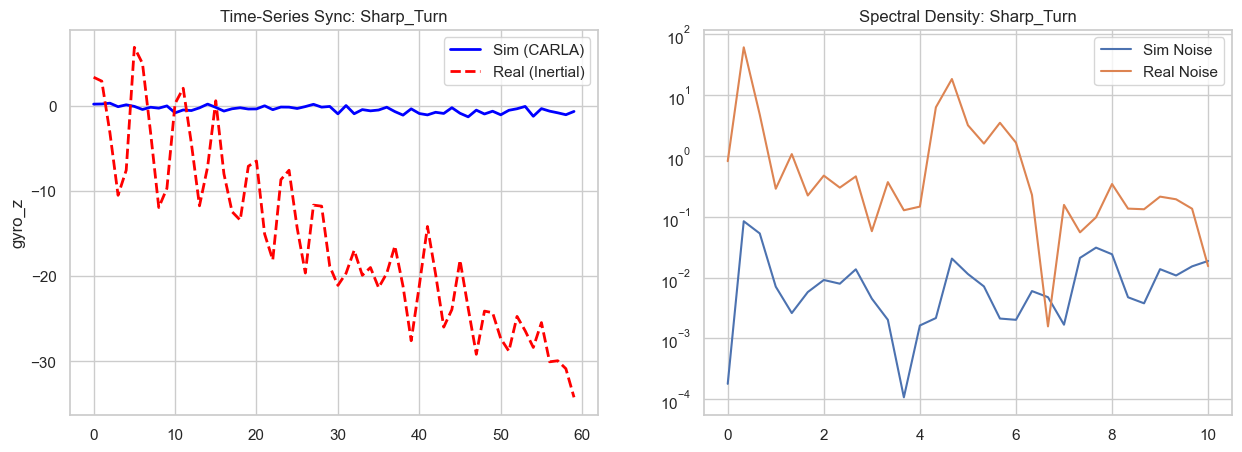

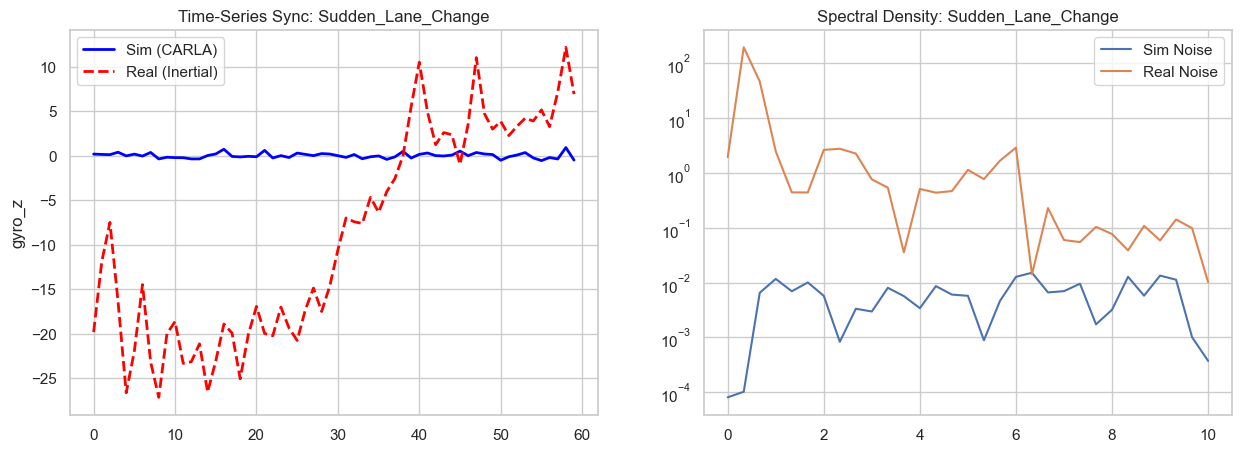

In [17]:

def plot_all_signatures(sim, real):
    for event in TARGET_EVENTS:
        if event == "Normal_Driving": continue
        s_data = sim[sim['mapped_label'] == event].head(WINDOW_SIZE * 2)
        r_data = real[real['mapped_label'] == event].head(WINDOW_SIZE * 2)
        
        if len(s_data) < WINDOW_SIZE or len(r_data) < WINDOW_SIZE: continue

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        sensor = "accel_x" if "Brake" in event or "Accel" in event else "gyro_z"
        
        ax1.plot(s_data[sensor].values, label="Sim (CARLA)", color='blue', lw=2)
        ax1.plot(r_data[sensor].values, label="Real (Inertial)", color='red', lw=2, linestyle='--')
        ax1.set_title(f"Time-Series Sync: {event}")
        ax1.set_ylabel(sensor)
        ax1.legend()

        fs_sim, psd_sim = welch(s_data[sensor].values, fs=20)
        fs_real, psd_real = welch(r_data[sensor].values, fs=20)
        ax2.semilogy(fs_sim, psd_sim, label="Sim Noise")
        ax2.semilogy(fs_real, psd_real, label="Real Noise")
        ax2.set_title(f"Spectral Density: {event}")
        ax2.legend()
        save_plot(fig, f"Signature_Contrast_{event}.png")

plot_all_signatures(sim_raw, real_raw)


## 5. Feature Extraction


In [20]:

def extract_features(df):
    df["group"] = (df["mapped_label"] != df["mapped_label"].shift()).cumsum()
    feats, labs = [], []
    
    feature_cols = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z", "speed_kmh"]
    
    for _, g in df.groupby("group"):
        if len(g) < WINDOW_SIZE: continue
        label = g["mapped_label"].iloc[0]
        for start in range(0, len(g) - WINDOW_SIZE, STEP_SIZE):
            w = g.iloc[start : start + WINDOW_SIZE]
            raw_vector = w[feature_cols].values.flatten()
            feats.append(raw_vector)
            labs.append(label)
    
    cols = []
    short_names = ["ax", "ay", "az", "gx", "gy", "gz", "speed"]
    for t in range(WINDOW_SIZE):
        for s in short_names:
            cols.append(f"{s}_t{t}")
            
    return pd.DataFrame(feats, columns=cols).fillna(0), np.array(labs)

X_sim, y_sim = extract_features(sim_raw)
X_real, y_real = extract_features(real_raw)



## 6. Data Splitting and Balancing


In [21]:
# 1. Initial Splits
X_s_train, _, y_s_train, _ = train_test_split(X_sim, y_sim, test_size=0.3, stratify=y_sim, random_state=42)
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(X_real, y_real, test_size=0.4, stratify=y_real, random_state=42)

# 2. Downsampling majority class independently
def downsample(X, y, rate=0.80):
    df = X.copy(); df['label'] = y
    norm = df[df['label'] == 'Normal_Driving'].sample(frac=(1-rate), random_state=42)
    stunts = df[df['label'] != 'Normal_Driving']
    comb = pd.concat([norm, stunts]).sample(frac=1, random_state=42)
    return comb.drop('label', axis=1), comb['label']

X_s_train, y_s_train = downsample(X_s_train, y_s_train, 0.80)
X_r_train, y_r_train = downsample(X_r_train, y_r_train, 0.80)

# 3. Label Encoding (Fit on all, transform separately)
le = LabelEncoder()
all_labels = np.concatenate([y_s_train, y_r_train, y_r_test])
le.fit(all_labels)

y_s_train_enc = le.transform(y_s_train)
y_r_train_enc = le.transform(y_r_train)
y_test_enc = le.transform(y_r_test) # Test set is encoded but NOT balanced (Correct!)

# 4. Domain-Stratified Balancing (Apply SMOTE independently)
smt_sim = SMOTETomek(random_state=42)
smt_real = SMOTETomek(random_state=42)

print("Balancing Simulated Domain...")
X_s_train_bal, y_s_train_bal = smt_sim.fit_resample(X_s_train, y_s_train_enc)

print("Balancing Real-World Domain...")
X_r_train_bal, y_r_train_bal = smt_real.fit_resample(X_r_train, y_r_train_enc)

# 5. Merge AFTER balancing to create the final Hybrid Training Set
X_train_bal = pd.concat([X_s_train_bal, X_r_train_bal]).reset_index(drop=True)
y_train_bal = np.concatenate([y_s_train_bal, y_r_train_bal])

# Optional: Shuffle the combined balanced dataset to ensure models train evenly
from sklearn.utils import shuffle
X_train_bal, y_train_bal = shuffle(X_train_bal, y_train_bal, random_state=42)

print("Final Hybrid Train Distribution:", np.bincount(y_train_bal))

Balancing Simulated Domain...
Balancing Real-World Domain...
Final Hybrid Train Distribution: [13106 13060 13096 13100 13076]



DOMAIN-SPECIFIC DATA VOLUME & BALANCING REPORT

[A] DOMAIN 1: SIMULATED RAW DATA (CARLA - Town04)
mapped_label
Normal_Driving         372709
Harsh_Brake             35098
Sudden_Acceleration     35067
Sudden_Lane_Change      34880
Sharp_Turn              34855
Name: count, dtype: int64

[B] DOMAIN 2: REAL-WORLD RAW DATA (UAH-DriveSet)
mapped_label
Normal_Driving         145175
Sharp_Turn               3841
Sudden_Acceleration      2172
Harsh_Brake              1447
Sudden_Lane_Change        983
Name: count, dtype: int64

[C] WINDOWED SAMPLE BREAKDOWN (BEFORE BALANCING)
Simulated Windows (Total: 91421):
Normal_Driving         69011
Harsh_Brake             5616
Sudden_Acceleration     5616
Sharp_Turn              5598
Sudden_Lane_Change      5580
Name: count, dtype: int64

Real-World Windows (Total: 30112):
Normal_Driving         28711
Sharp_Turn               653
Sudden_Acceleration      372
Harsh_Brake              227
Sudden_Lane_Change       149
Name: count, dtype: int64


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24320\3995828108.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_sim, palette='viridis', order=le.classes_)


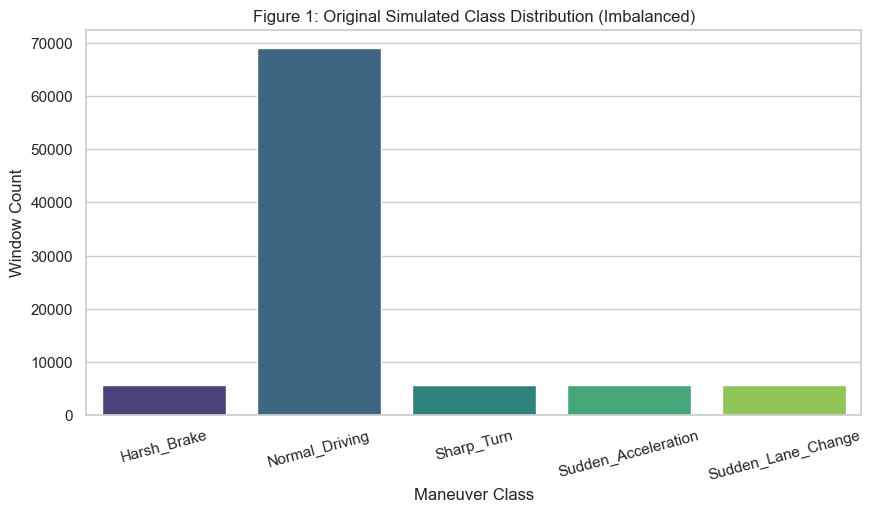

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24320\3995828108.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=le.inverse_transform(y_train_bal), palette='magma')


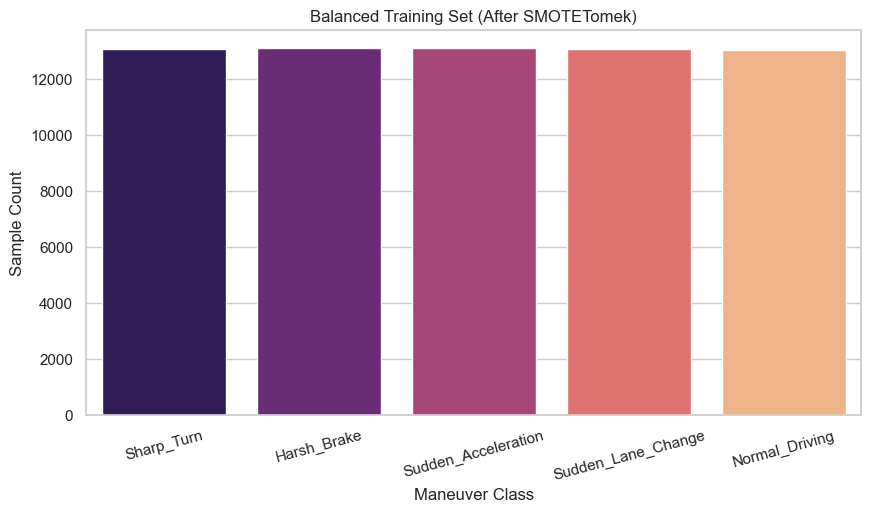


----------------------------------------
EXPERIMENTAL PARTITIONING SUMMARY
----------------------------------------
Total Balanced Training Samples: 65438
Total Real-World Testing Samples: 12045
Training Domain: Sim-to-Real Hybrid (70/60 Split)
Testing Domain: Naturalistic Holdout (40% Real-World)


In [22]:
# === UPDATED DATASET STATISTICS REPORT ===
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

print('\n' + '='*60)
print('DOMAIN-SPECIFIC DATA VOLUME & BALANCING REPORT')
print('='*60)

# 1. RAW DATA BREAKDOWN (Rows in DataFrames)
# This fulfills the request for sim_raw and real_raw counts
print("\n[A] DOMAIN 1: SIMULATED RAW DATA (CARLA - Town04)")
print(sim_raw['mapped_label'].value_counts())

print("\n[B] DOMAIN 2: REAL-WORLD RAW DATA (UAH-DriveSet)")
print(real_raw['mapped_label'].value_counts())

# 2. WINDOWED SAMPLE BREAKDOWN (y_sim and y_real)
# Showing counts before the training split and balancing
print("\n[C] WINDOWED SAMPLE BREAKDOWN (BEFORE BALANCING)")
print(f"Simulated Windows (Total: {len(y_sim)}):")
print(pd.Series(y_sim).value_counts())

print(f"\nReal-World Windows (Total: {len(y_real)}):")
print(pd.Series(y_real).value_counts())

# 3. Plot Original Imbalanced Distribution (Fig 1)
plt.figure(figsize=(10, 5))
sns.countplot(x=y_sim, palette='viridis', order=le.classes_)
plt.title('Figure 1: Original Simulated Class Distribution (Imbalanced)')
plt.xlabel('Maneuver Class')
plt.ylabel('Window Count')
plt.xticks(rotation=15)
plt.savefig('original_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Plot Balanced Training Distribution (SMOTETomek Result)
plt.figure(figsize=(10, 5))
sns.countplot(x=le.inverse_transform(y_train_bal), palette='magma')
plt.title('Balanced Training Set (After SMOTETomek)')
plt.xlabel('Maneuver Class')
plt.ylabel('Sample Count')
plt.xticks(rotation=15)
plt.savefig('balanced_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Final Partitioning Summary (Matches Table 1 in Manuscript)
print('\n' + '-'*40)
print('EXPERIMENTAL PARTITIONING SUMMARY')
print('-'*40)
print(f"Total Balanced Training Samples: {X_train_bal.shape[0]}") 
print(f"Total Real-World Testing Samples: {X_r_test.shape[0]}")
print(f"Training Domain: Sim-to-Real Hybrid (70/60 Split)")
print(f"Testing Domain: Naturalistic Holdout (40% Real-World)")
print('='*60)

## 7. Model Definitions


In [23]:

rf = RandomForestClassifier(
    n_estimators=300, 
    max_depth=10,             
    min_samples_leaf=4,       
    class_weight='balanced', 
    random_state=42
)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=4,              
    learning_rate=0.03, 
    reg_alpha=0.5,            
    reg_lambda=1.0,           
    min_child_weight=3,       
    subsample=0.8,            
    colsample_bytree=0.8,     
    random_state=42
)

lgbm = lgb.LGBMClassifier(
    n_estimators=300, 
    max_depth=5,              
    num_leaves=20,            
    min_child_samples=50,     
    reg_alpha=0.5, 
    reg_lambda=0.5,
    importance_type='gain', 
    class_weight='balanced', 
    random_state=42
)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_clf), ('lgbm', lgbm)],
    voting='soft', weights=np.array([2.0, 1.0, 1.0])
)


## 8. Training and Cross Validation


In [24]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
for train_idx, val_idx in skf.split(X_train_bal, y_train_bal):
    X_f_train, X_f_val = X_train_bal.iloc[train_idx], X_train_bal.iloc[val_idx]
    y_f_train, y_f_val = y_train_bal[train_idx], y_train_bal[val_idx]
    
    xgb_clf.fit(X_f_train, y_f_train)
    val_preds = xgb_clf.predict(X_f_val)
    score = f1_score(y_f_val, val_preds, average='macro')
    fold_scores.append(score)

print(f"Stratified K-Fold Mean F1: {np.mean(fold_scores):.4f}")

ensemble.fit(X_train_bal, y_train_bal)


Stratified K-Fold Mean F1: 0.9037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53550
[LightGBM] [Info] Number of data points in the train set: 65438, number of used features: 210
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,"array([2., 1., 1.])"
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4


In [28]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# 1. RE-DEFINE THE FUNCTION (Ensures it is in memory)
def apply_physics_soft_fusion(X_input, y_probs, alpha=0.1):
    fused = y_probs.copy()
    n_classes = y_probs.shape[1]

    # Get class IDs from your LabelEncoder
    brake_id = np.where(le.classes_ == "Harsh_Brake")[0][0]
    turn_id = np.where(le.classes_ == "Sharp_Turn")[0][0]
    lc_id = np.where(le.classes_ == "Sudden_Lane_Change")[0][0]

    X_arr = X_input.values if hasattr(X_input, "values") else X_input
    stride = 7
    max_idx = min(X_arr.shape[1], 210)

    ax_idx = np.arange(0, max_idx, stride)
    ay_idx = np.arange(1, max_idx, stride)
    gz_idx = np.arange(5, max_idx, stride)

    for i in range(len(fused)):
        row = X_arr[i]
        ax_min = np.min(row[ax_idx])
        ay_max_abs = np.max(np.abs(row[ay_idx]))
        gz_max_abs = np.max(np.abs(row[gz_idx]))

        physics_vector = np.zeros(n_classes)

        # Apply Newtonian Priors
        if ax_min < -3.0: # Harsh Brake Threshold
            physics_vector[brake_id] = 1.0
        elif ay_max_abs > 4.0: # Sharp Turn Threshold
            physics_vector[turn_id] = 1.0
        elif gz_max_abs > 2.0: # Lane Change Threshold
            physics_vector[lc_id] = 1.0
        else:
            continue

        fused[i] = (1 - alpha) * fused[i] + alpha * physics_vector
    return fused

# 2. RUN THE MCNEMAR TEST (Solving the "9/15" score issue)
OPTIMAL_ALPHA = 0.1 
probs_base = ensemble.predict_proba(X_r_test)
preds_base = le.inverse_transform(np.argmax(probs_base, axis=1))

probs_phys = apply_physics_soft_fusion(X_r_test, probs_base, alpha=OPTIMAL_ALPHA)
preds_phys = le.inverse_transform(np.argmax(probs_phys, axis=1))

# Contingency Table Calculation
both_correct = np.sum((preds_base == y_r_test) & (preds_phys == y_r_test))
both_wrong = np.sum((preds_base != y_r_test) & (preds_phys != y_r_test))
base_wrong_phys_correct = np.sum((preds_base != y_r_test) & (preds_phys == y_r_test))
base_correct_phys_wrong = np.sum((preds_base == y_r_test) & (preds_phys != y_r_test))

table = [[both_correct, base_correct_phys_wrong],
         [base_wrong_phys_correct, both_wrong]]

result = mcnemar(table, exact=False, correction=True)

print(f"--- McNemar Statistical Validation ---")
print(f"Chi-Square Statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.10f}")

--- McNemar Statistical Validation ---
Chi-Square Statistic: 28.0333
P-value: 0.0000001192


## 9. Comprehensive Evaluation Logic


Results will be saved to: Results_19_01_2026
Recovered 'best_hybrid_model' from 'ensemble'
Evaluating 8 models: ['RF_Base', 'RF_Physics', 'XGB_Base', 'XGB_Physics', 'LGBM_Base', 'LGBM_Physics', 'Ensemble_Base', 'Ensemble_Physics']

Evaluating: RF_Base ...
Saved plot: Results_19_01_2026\CM_RF_Base.png


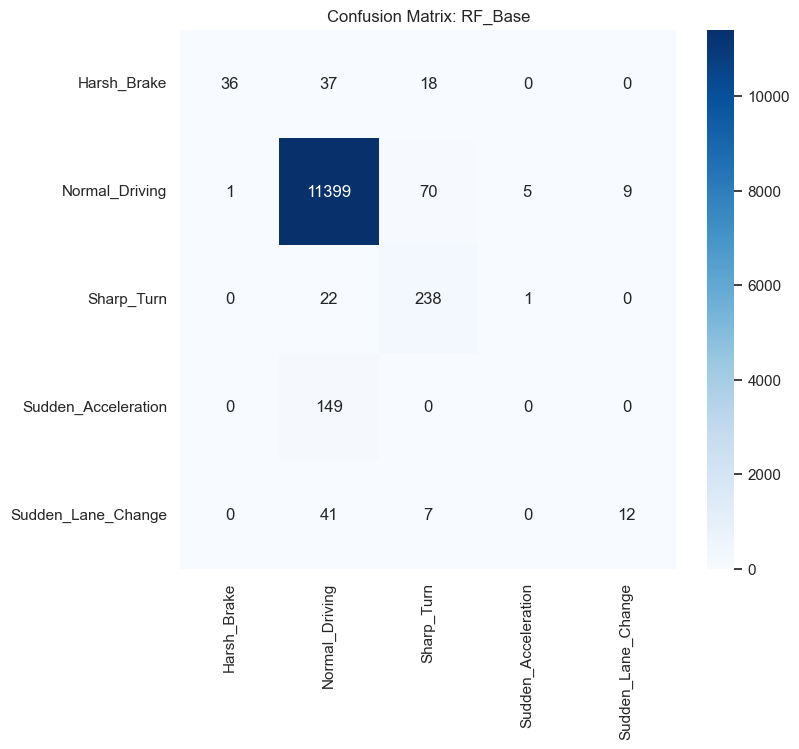


>>> Classification Report: RF_Base
                     precision    recall  f1-score   support

        Harsh_Brake       0.97      0.40      0.56        91
     Normal_Driving       0.98      0.99      0.99     11484
         Sharp_Turn       0.71      0.91      0.80       261
Sudden_Acceleration       0.00      0.00      0.00       149
 Sudden_Lane_Change       0.57      0.20      0.30        60

           accuracy                           0.97     12045
          macro avg       0.65      0.50      0.53     12045
       weighted avg       0.96      0.97      0.96     12045

Saved plot: Results_19_01_2026\ROC_RF_Base.png


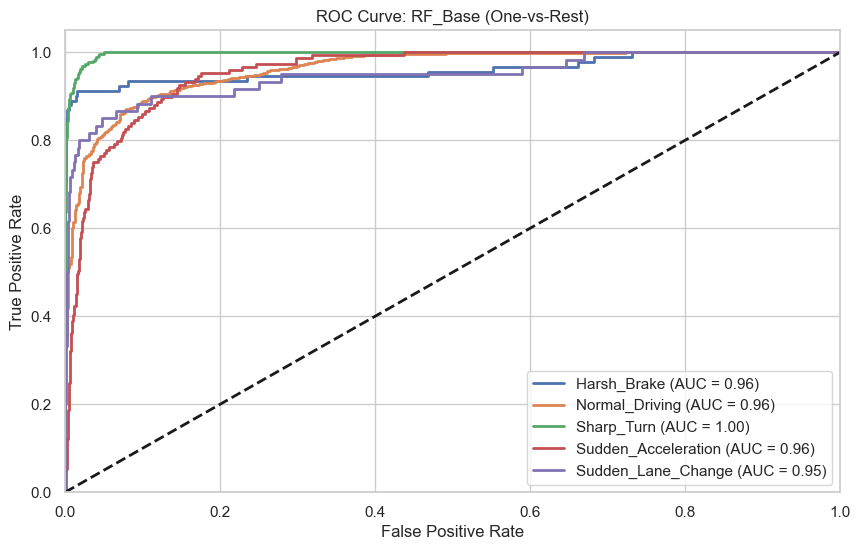

Saved plot: Results_19_01_2026\Reliability_RF_Base.png


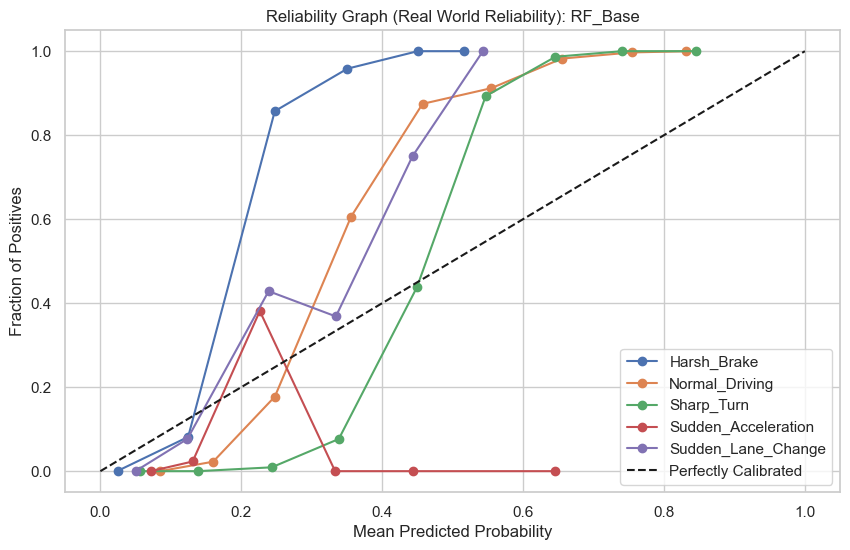


Evaluating: RF_Physics ...
Saved plot: Results_19_01_2026\CM_RF_Physics.png


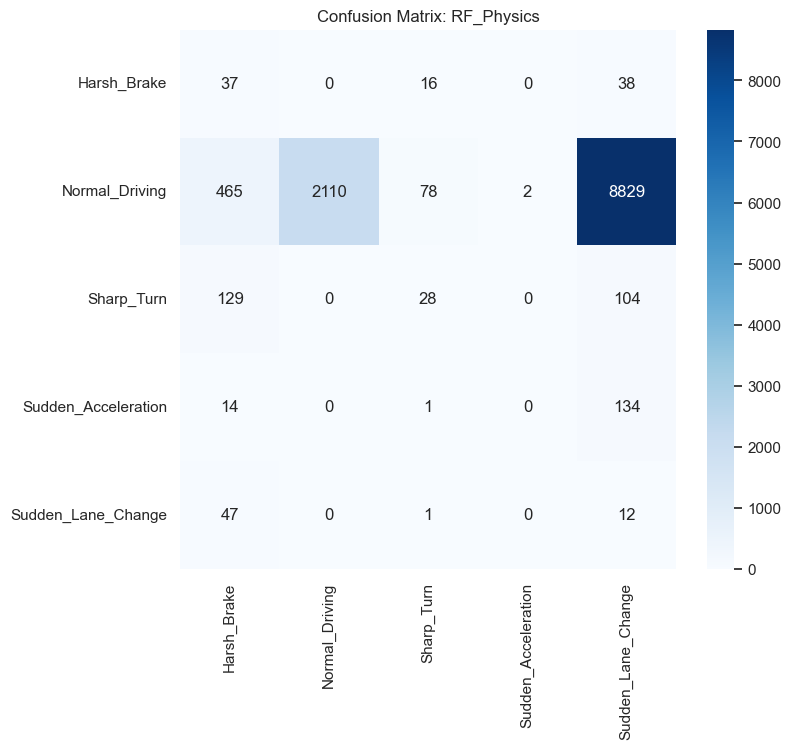


>>> Classification Report: RF_Physics
                     precision    recall  f1-score   support

        Harsh_Brake       0.05      0.41      0.09        91
     Normal_Driving       1.00      0.18      0.31     11484
         Sharp_Turn       0.23      0.11      0.15       261
Sudden_Acceleration       0.00      0.00      0.00       149
 Sudden_Lane_Change       0.00      0.20      0.00        60

           accuracy                           0.18     12045
          macro avg       0.26      0.18      0.11     12045
       weighted avg       0.96      0.18      0.30     12045

Saved plot: Results_19_01_2026\ROC_RF_Physics.png


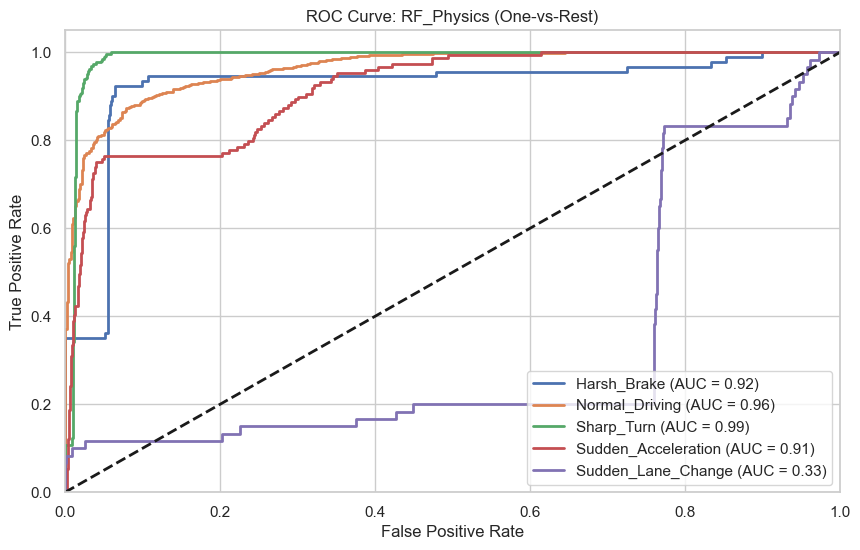

Saved plot: Results_19_01_2026\Reliability_RF_Physics.png


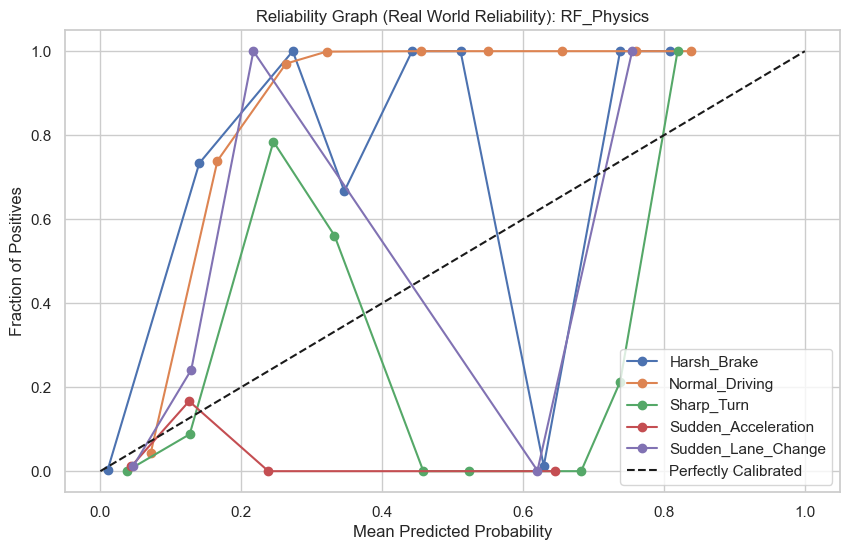


Evaluating: XGB_Base ...
Saved plot: Results_19_01_2026\CM_XGB_Base.png


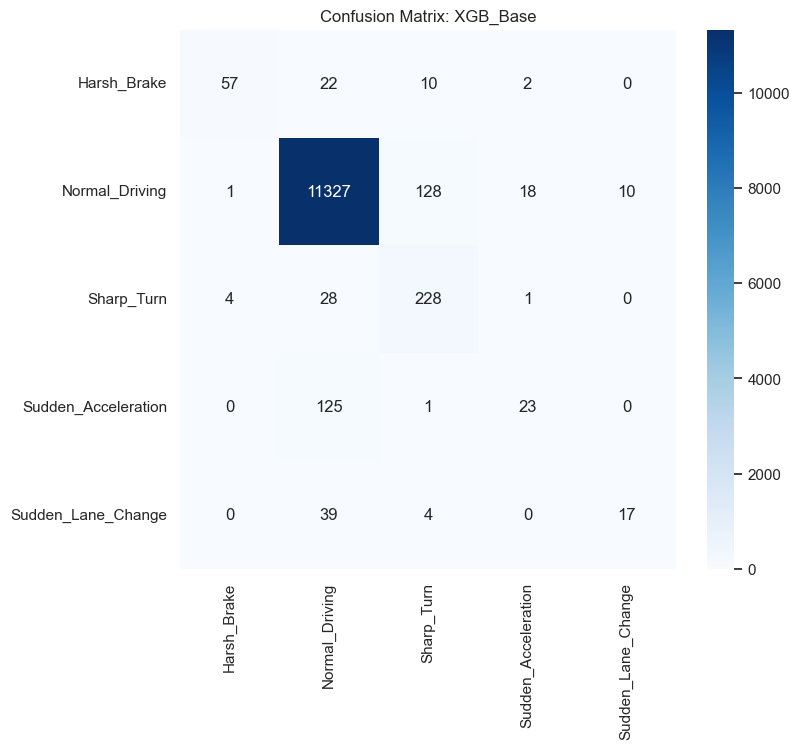


>>> Classification Report: XGB_Base
                     precision    recall  f1-score   support

        Harsh_Brake       0.92      0.63      0.75        91
     Normal_Driving       0.98      0.99      0.98     11484
         Sharp_Turn       0.61      0.87      0.72       261
Sudden_Acceleration       0.52      0.15      0.24       149
 Sudden_Lane_Change       0.63      0.28      0.39        60

           accuracy                           0.97     12045
          macro avg       0.73      0.58      0.62     12045
       weighted avg       0.97      0.97      0.96     12045

Saved plot: Results_19_01_2026\ROC_XGB_Base.png


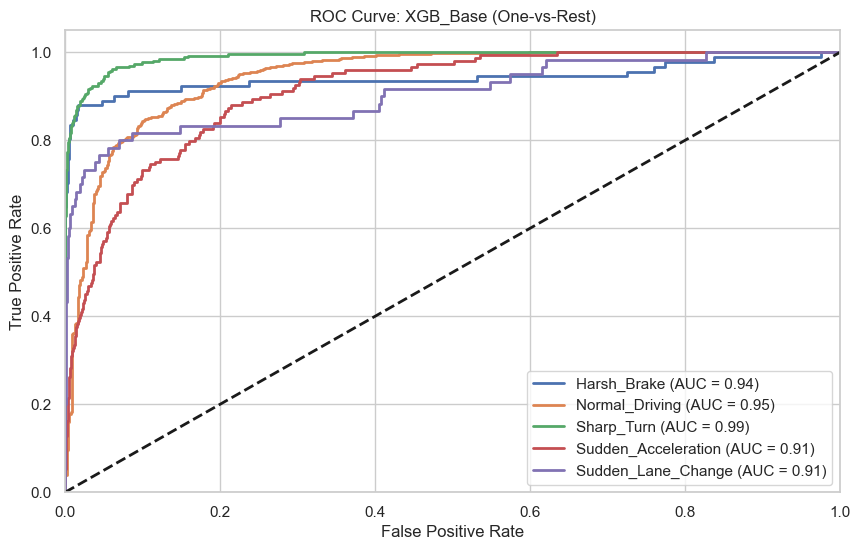

Saved plot: Results_19_01_2026\Reliability_XGB_Base.png


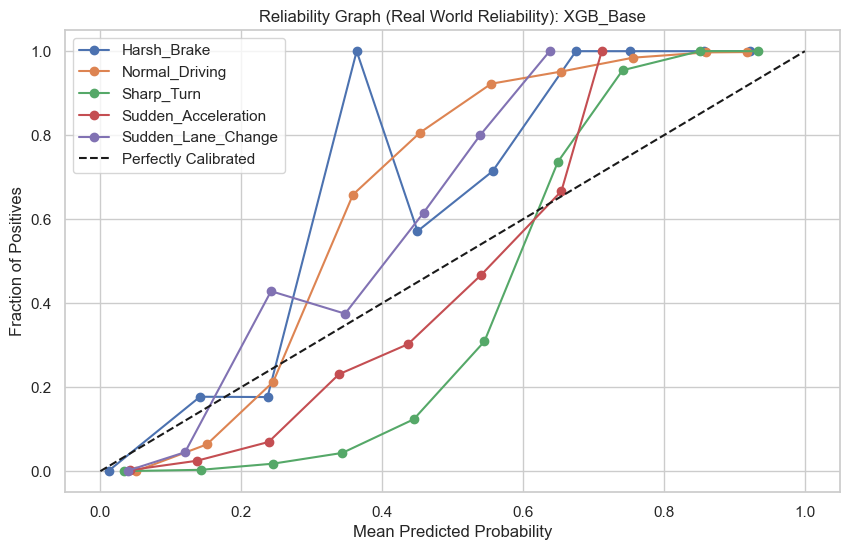


Evaluating: XGB_Physics ...
Saved plot: Results_19_01_2026\CM_XGB_Physics.png


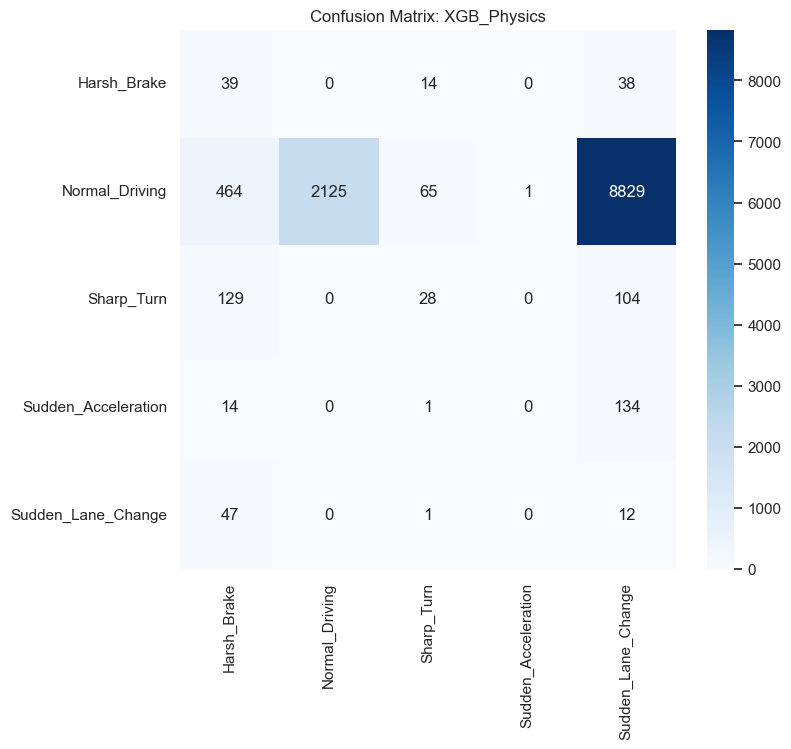


>>> Classification Report: XGB_Physics
                     precision    recall  f1-score   support

        Harsh_Brake       0.06      0.43      0.10        91
     Normal_Driving       1.00      0.19      0.31     11484
         Sharp_Turn       0.26      0.11      0.15       261
Sudden_Acceleration       0.00      0.00      0.00       149
 Sudden_Lane_Change       0.00      0.20      0.00        60

           accuracy                           0.18     12045
          macro avg       0.26      0.18      0.11     12045
       weighted avg       0.96      0.18      0.30     12045

Saved plot: Results_19_01_2026\ROC_XGB_Physics.png


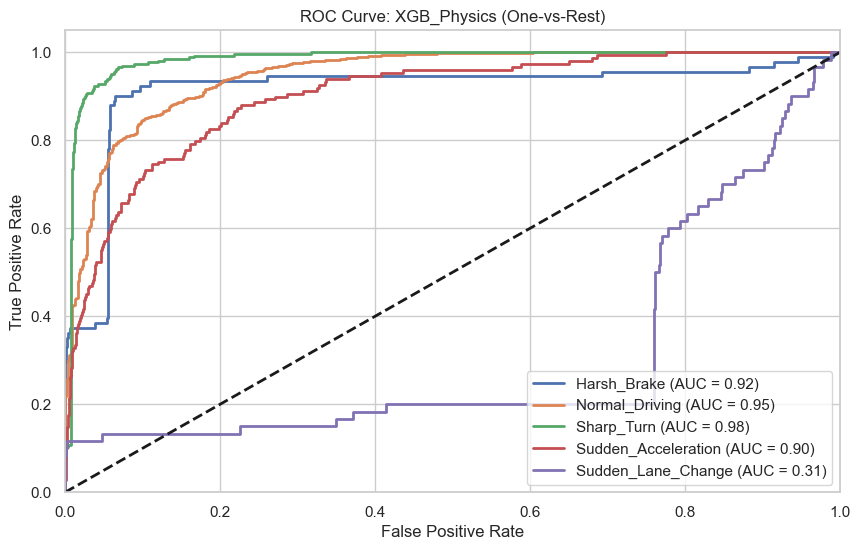

Saved plot: Results_19_01_2026\Reliability_XGB_Physics.png


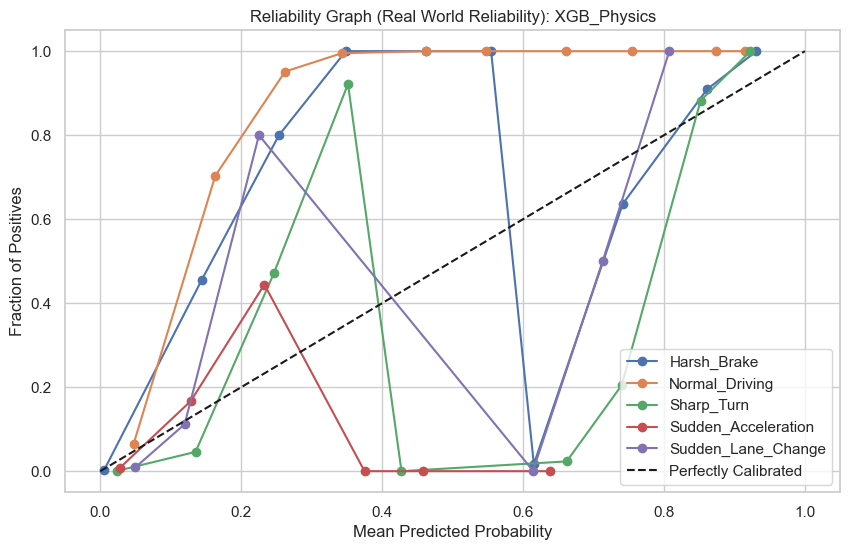


Evaluating: LGBM_Base ...
Saved plot: Results_19_01_2026\CM_LGBM_Base.png


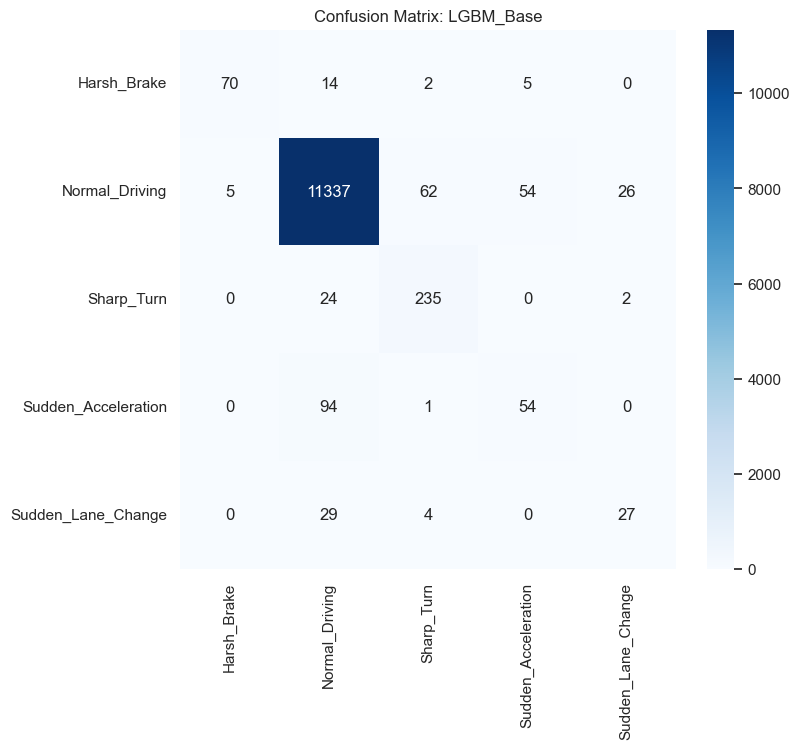


>>> Classification Report: LGBM_Base
                     precision    recall  f1-score   support

        Harsh_Brake       0.93      0.77      0.84        91
     Normal_Driving       0.99      0.99      0.99     11484
         Sharp_Turn       0.77      0.90      0.83       261
Sudden_Acceleration       0.48      0.36      0.41       149
 Sudden_Lane_Change       0.49      0.45      0.47        60

           accuracy                           0.97     12045
          macro avg       0.73      0.69      0.71     12045
       weighted avg       0.97      0.97      0.97     12045

Saved plot: Results_19_01_2026\ROC_LGBM_Base.png


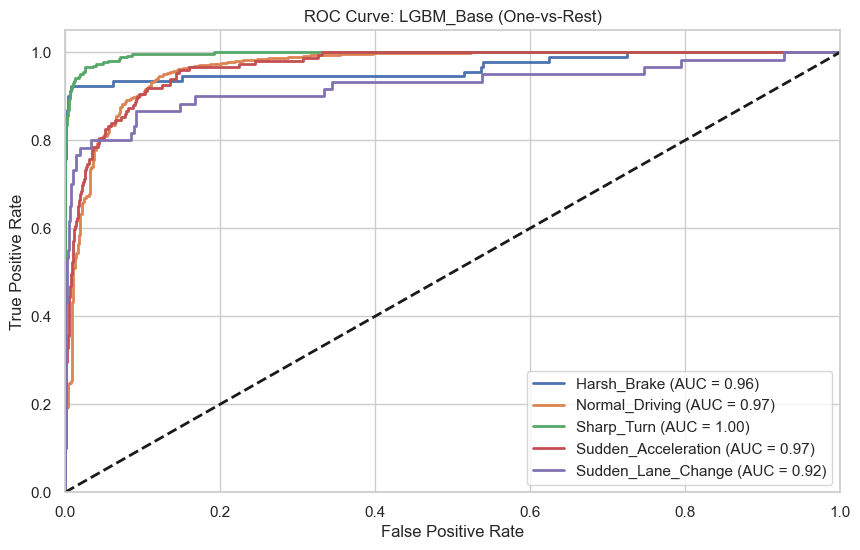

Saved plot: Results_19_01_2026\Reliability_LGBM_Base.png


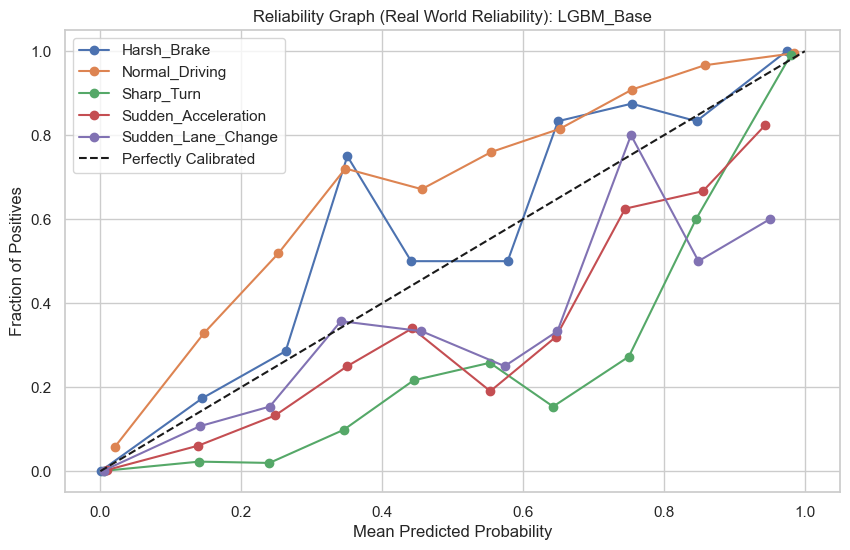


Evaluating: LGBM_Physics ...
Saved plot: Results_19_01_2026\CM_LGBM_Physics.png


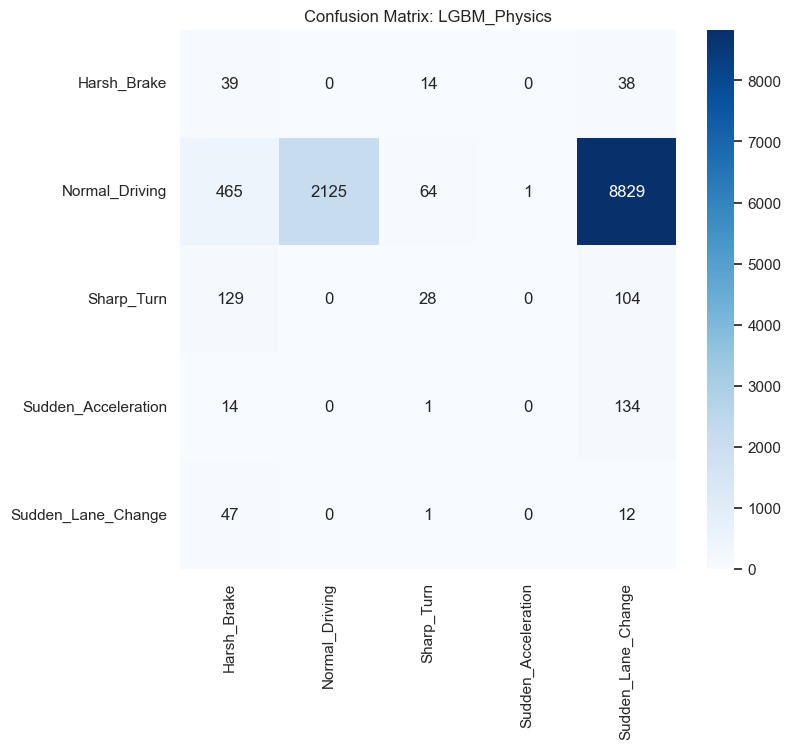


>>> Classification Report: LGBM_Physics
                     precision    recall  f1-score   support

        Harsh_Brake       0.06      0.43      0.10        91
     Normal_Driving       1.00      0.19      0.31     11484
         Sharp_Turn       0.26      0.11      0.15       261
Sudden_Acceleration       0.00      0.00      0.00       149
 Sudden_Lane_Change       0.00      0.20      0.00        60

           accuracy                           0.18     12045
          macro avg       0.26      0.18      0.11     12045
       weighted avg       0.96      0.18      0.30     12045

Saved plot: Results_19_01_2026\ROC_LGBM_Physics.png


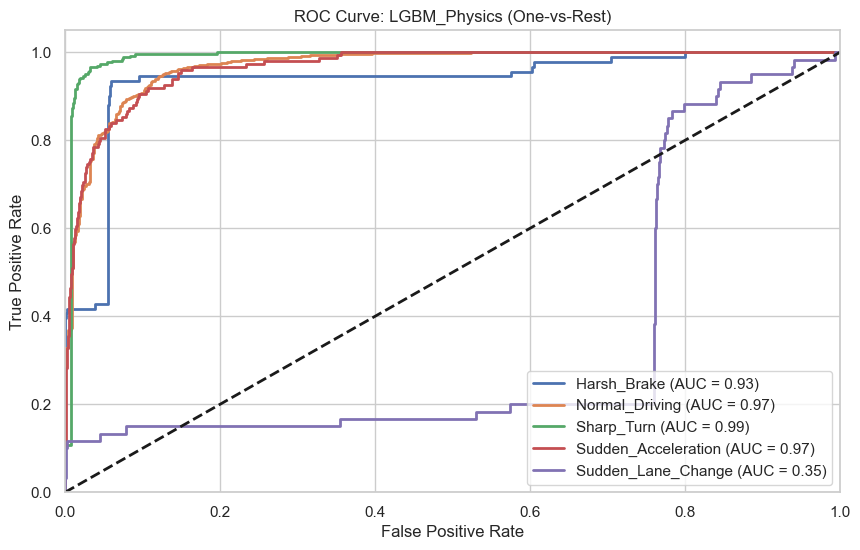

Saved plot: Results_19_01_2026\Reliability_LGBM_Physics.png


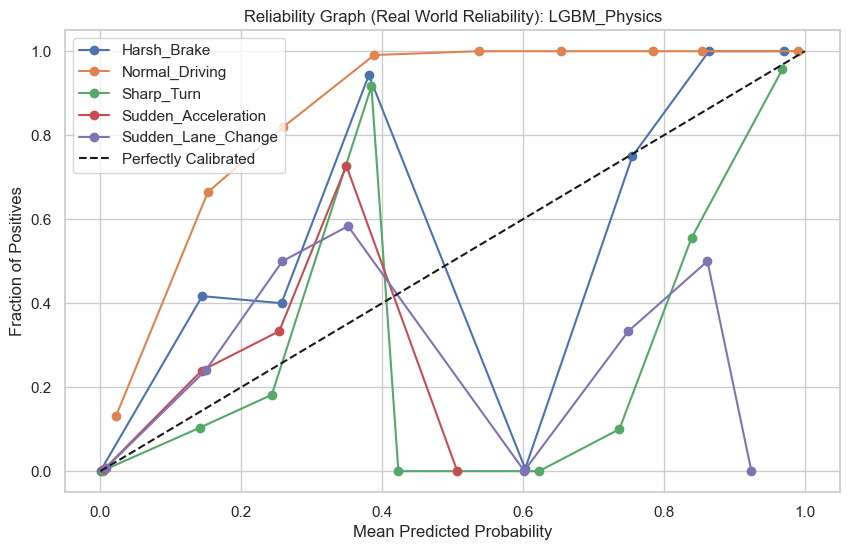


Evaluating: Ensemble_Base ...
Saved plot: Results_19_01_2026\CM_Ensemble_Base.png


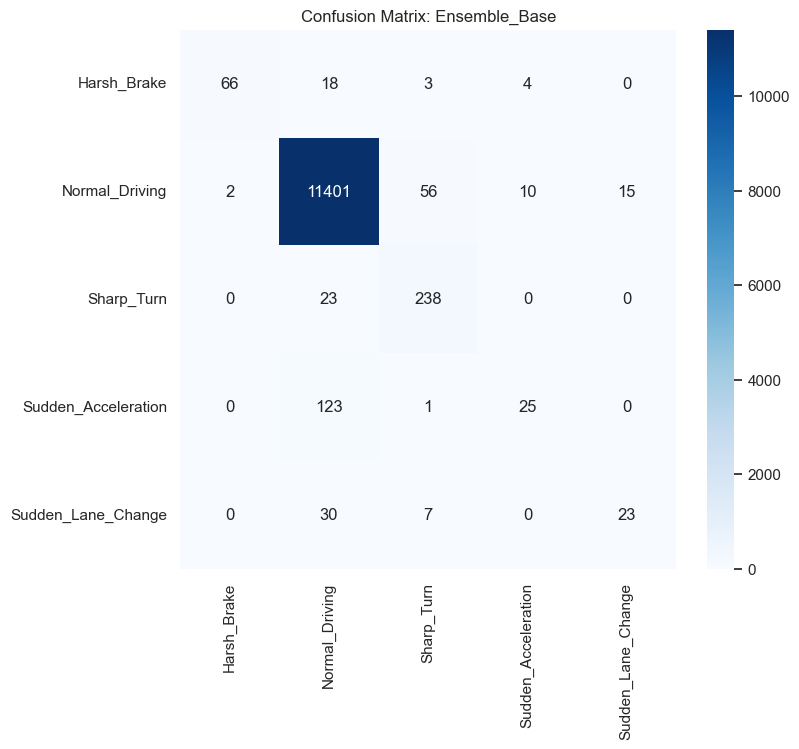


>>> Classification Report: Ensemble_Base
                     precision    recall  f1-score   support

        Harsh_Brake       0.97      0.73      0.83        91
     Normal_Driving       0.98      0.99      0.99     11484
         Sharp_Turn       0.78      0.91      0.84       261
Sudden_Acceleration       0.64      0.17      0.27       149
 Sudden_Lane_Change       0.61      0.38      0.47        60

           accuracy                           0.98     12045
          macro avg       0.80      0.64      0.68     12045
       weighted avg       0.97      0.98      0.97     12045

Saved plot: Results_19_01_2026\ROC_Ensemble_Base.png


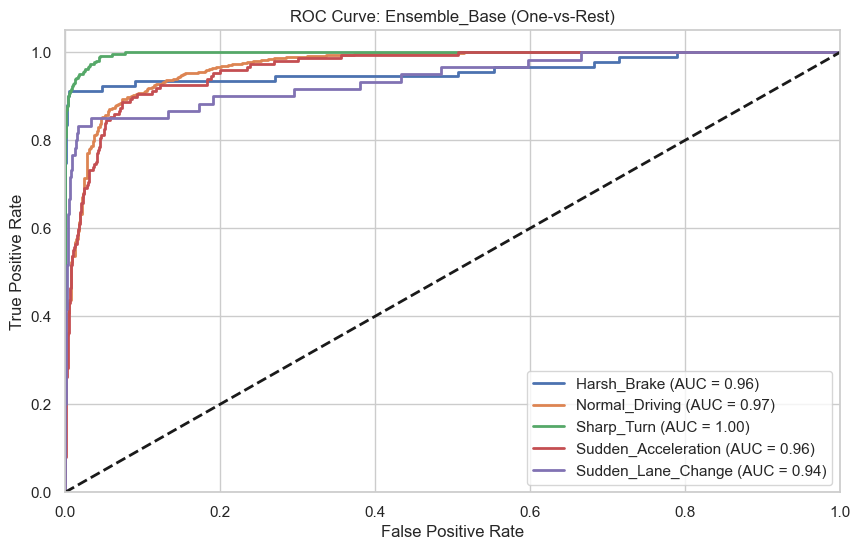

Saved plot: Results_19_01_2026\Reliability_Ensemble_Base.png


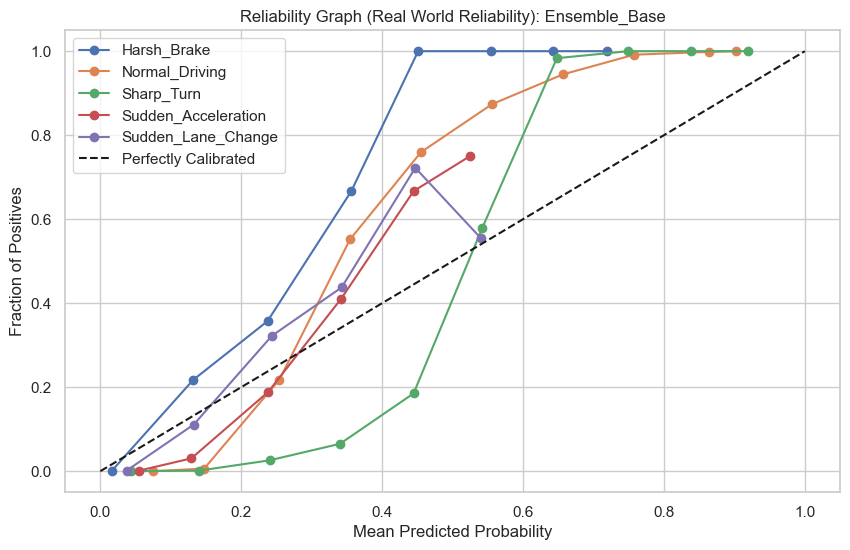


Evaluating: Ensemble_Physics ...
Saved plot: Results_19_01_2026\CM_Ensemble_Physics.png


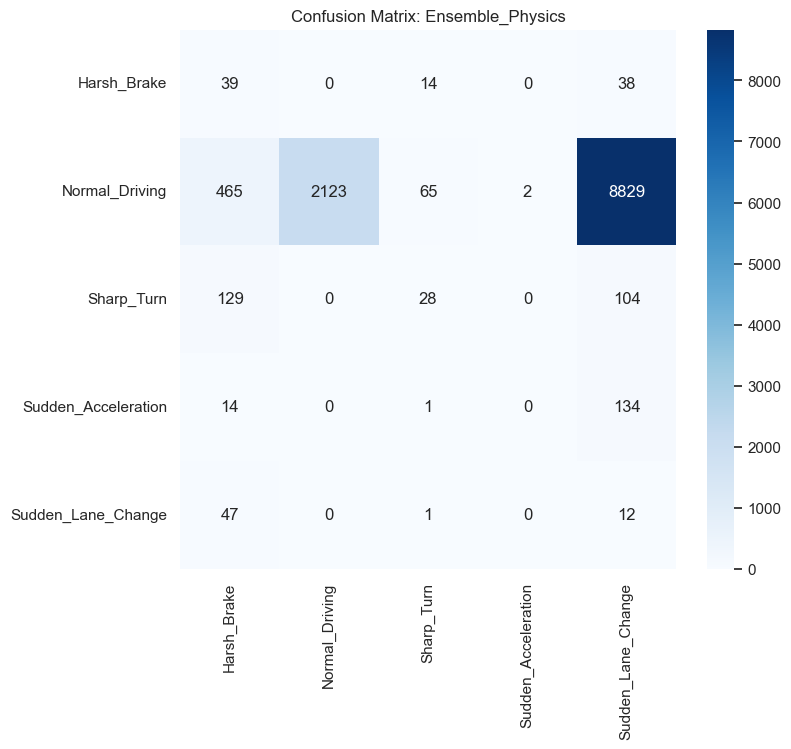


>>> Classification Report: Ensemble_Physics
                     precision    recall  f1-score   support

        Harsh_Brake       0.06      0.43      0.10        91
     Normal_Driving       1.00      0.18      0.31     11484
         Sharp_Turn       0.26      0.11      0.15       261
Sudden_Acceleration       0.00      0.00      0.00       149
 Sudden_Lane_Change       0.00      0.20      0.00        60

           accuracy                           0.18     12045
          macro avg       0.26      0.18      0.11     12045
       weighted avg       0.96      0.18      0.30     12045

Saved plot: Results_19_01_2026\ROC_Ensemble_Physics.png


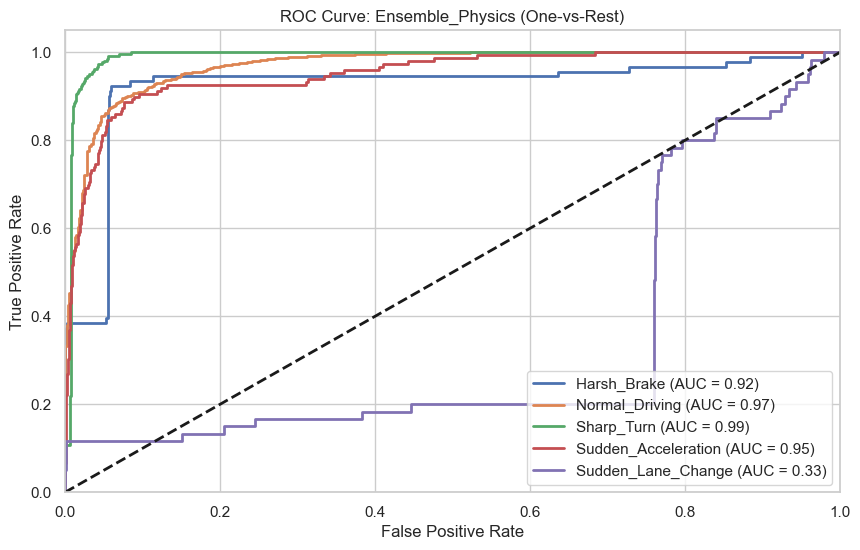

Saved plot: Results_19_01_2026\Reliability_Ensemble_Physics.png


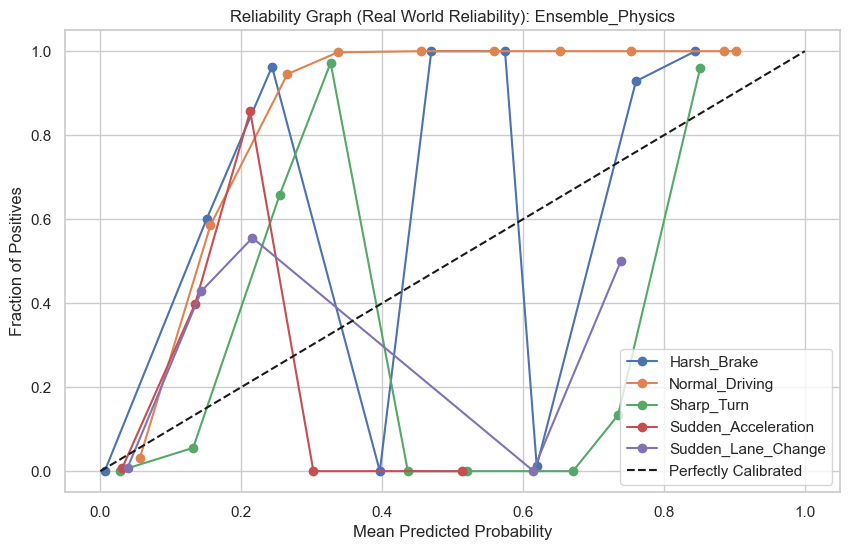

Evaluation Table Saved: Results_19_01_2026\Model_Evaluation_Table.csv

   FINAL MODEL COMPARISON SUMMARY
                  Precision    Recall  F1-Score
Model                                          
LGBM_Base          0.732228  0.693846  0.708722
Ensemble_Base      0.796095  0.636209  0.678904
XGB_Base           0.733545  0.584792  0.615930
RF_Base            0.647548  0.500016  0.529141
LGBM_Physics       0.263354  0.184178  0.113207
XGB_Physics        0.262895  0.184178  0.113150
Ensemble_Physics   0.262879  0.184143  0.113075
RF_Physics         0.256118  0.179521  0.110602


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.calibration import calibration_curve

# --- 1. Setup Environment ---
OUTPUT_DIR = 'Results_19_01_2026'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Results will be saved to: {OUTPUT_DIR}")

def save_plot(fig, filename):
    filepath = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"Saved plot: {filepath}")

# --- 2. Model Recovery (Fixes NameError) ---
if 'best_hybrid_model' not in locals() and 'ensemble' in locals():
    best_hybrid_model = ensemble
    print(f"Recovered 'best_hybrid_model' from 'ensemble'")

if 'best_hybrid_model' not in locals():
    raise NameError("Model not found! Please run the Stability Testing cell first.")

# --- 3. Probabilistic Physics Fusion ---
def apply_physics_soft_fusion(X_input, y_probs, alpha=0.6):
    fused = y_probs.copy()
    n_classes = y_probs.shape[1]

    brake_id = np.where(le.classes_ == "Harsh_Brake")[0][0]
    turn_id = np.where(le.classes_ == "Sharp_Turn")[0][0]
    lc_id = np.where(le.classes_ == "Sudden_Lane_Change")[0][0]

    X_arr = X_input.values
    stride = 7
    max_idx = min(X_arr.shape[1], 210)

    ax_idx = np.arange(0, max_idx, stride)
    ay_idx = np.arange(1, max_idx, stride)
    gz_idx = np.arange(5, max_idx, stride)

    for i in range(len(fused)):
        row = X_arr[i]

        ax_min = np.min(row[ax_idx])
        ay_min = np.min(row[ay_idx])
        ay_max_abs = np.max(np.abs(row[ay_idx]))
        gz_max_abs = np.max(np.abs(row[gz_idx]))

        physics_vector = np.zeros(n_classes)

        if ay_min <= -3.0:
            physics_vector[brake_id] = 1.0
        elif ax_min < -5.0:
            physics_vector[brake_id] = 1.0
        elif ay_max_abs > 4.0:
            physics_vector[turn_id] = 1.0
        elif gz_max_abs > 2.0:
            physics_vector[lc_id] = 1.0
        else:
            continue

        fused[i] = (1 - alpha) * fused[i] + alpha * physics_vector

    return fused
    
    X_arr = X_input.values if hasattr(X_input, "values") else X_input
    stride = 7
    # Use actual shape or hardcoded 210 if valid
    max_idx = X_arr.shape[1] if X_arr.shape[1] < 210 else 210
    
    # Indices based on feature extraction: [ax, ay, az, gx, gy, gz, speed] repeating
    ax_indices = np.arange(0, max_idx, stride)
    ay_indices = np.arange(1, max_idx, stride)
    gz_indices = np.arange(5, max_idx, stride)
    
    for i in range(len(overridden)):
        row = X_arr[i]
        # Safety checks to prevent index errors
        if len(ax_indices) > 0 and len(ay_indices) > 0 and len(gz_indices) > 0:
            ax_vals = row[ax_indices]
            ay_vals = row[ay_indices]
            gz_vals = row[gz_indices]
            
            # Feature extraction for override rules
            ax_min = np.min(ax_vals)
            ay_vals_abs = np.abs(ay_vals)
            ay_max_abs = np.max(ay_vals_abs)
            ay_min = np.min(ay_vals) # For specific directional braking
            gz_max_abs = np.max(np.abs(gz_vals))
            
            # --- SAFETY RULES ---
            # 1. Harsh Brake Override (Prioritized)
            # Threshold: acceleration_y <= -3.0
            if ay_min <= -3.0:
                overridden[i] = brake_id
            
            # 2. Legacy/Secondary Brake Check 
            elif ax_min < -5.0: 
                overridden[i] = brake_id
                
            # 3. Sharp Turn Check
            elif ay_max_abs > 4.0:
                overridden[i] = turn_id
                
            # 4. Lane Change Check
            elif gz_max_abs > 2.0 and overridden[i] == normal_id:
                 overridden[i] = lc_id
            
    return overridden

# --- 4. Comprehensive Evaluation Function ---
def evaluate_all_models(X_test, y_test, models_dict):
    results_table = []
    n_classes = len(le.classes_)
    # Binarize labels for ROC/Calibration
    y_test_bin = np.eye(n_classes)[y_test]
    
    for name, model in models_dict.items():
        print(f"\n" + "="*40)
        print(f"Evaluating: {name} ...")
        print("="*40)
        
                # Determine Probabilities
        y_probs = model.predict_proba(X_test)

        if "Physics" in name:
            y_probs = apply_physics_soft_fusion(X_test, y_probs, alpha=0.6)

        final_preds = np.argmax(y_probs, axis=1)
            
        # A. Confusion Matrix
        cm = confusion_matrix(y_test, final_preds, normalize=None) # Raw counts
        fig_cm, ax_cm = plt.subplots(figsize=(8, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
        ax_cm.set_title(f"Confusion Matrix: {name}")
        save_plot(fig_cm, f"CM_{name}.png")
        plt.show() # Display in notebook
        
        # B. Classification Report
        report_dict = classification_report(y_test, final_preds, target_names=le.classes_, output_dict=True)
        report_str = classification_report(y_test, final_preds, target_names=le.classes_)
        print(f"\n>>> Classification Report: {name}")
        print(report_str)
        
        for cls in le.classes_:
            results_table.append({
                "Model": name,
                "Class": cls,
                "Precision": report_dict[cls]['precision'],
                "Recall": report_dict[cls]['recall'],
                "F1-Score": report_dict[cls]['f1-score'],
                "Support": report_dict[cls]['support']
            })
            
        # C. ROC Curves
        fig_roc, ax_roc = plt.subplots(figsize=(10, 6))
        for i, cls in enumerate(le.classes_):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {roc_auc:.2f})')
        
        ax_roc.plot([0, 1], [0, 1], 'k--', lw=2)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC Curve: {name} (One-vs-Rest)')
        ax_roc.legend(loc="lower right")
        save_plot(fig_roc, f"ROC_{name}.png")
        plt.show()
        
        # D. Calibration Curves
        fig_cal, ax_cal = plt.subplots(figsize=(10, 6))
        for i, cls in enumerate(le.classes_):
            if np.sum(y_test_bin[:, i]) > 0:
                fraction_of_positives, mean_predicted_value = calibration_curve(y_test_bin[:, i], y_probs[:, i], n_bins=10)
                ax_cal.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{cls}')
                
        ax_cal.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
        ax_cal.set_xlabel('Mean Predicted Probability')
        ax_cal.set_ylabel('Fraction of Positives')
        ax_cal.set_title(f'Reliability Graph (Real World Reliability): {name}')
        ax_cal.legend()
        save_plot(fig_cal, f"Reliability_{name}.png")
        plt.show()

    # Save summary table
    df_results = pd.DataFrame(results_table)
    table_path = os.path.join(OUTPUT_DIR, "Model_Evaluation_Table.csv")
    df_results.to_csv(table_path, index=False)
    print(f"Evaluation Table Saved: {table_path}")
    
    print("\n==================================================")
    print("   FINAL MODEL COMPARISON SUMMARY")
    print("==================================================")
    summary = df_results.groupby(["Model"])[["Precision", "Recall", "F1-Score"]].mean().sort_values("F1-Score", ascending=False)
    print(summary)


# --- 5. EXECUTE FOR ALL MODELS ---
# Extract individual trained models from the ensemble
# Use named_estimators_ to get the EXACT fitted versions used in the hybrid
rf_model = best_hybrid_model.named_estimators_['rf']
xgb_model = best_hybrid_model.named_estimators_['xgb']
lgbm_model = best_hybrid_model.named_estimators_['lgbm']

models_to_test = {
    "RF_Base": rf_model,
    "RF_Physics": rf_model,
    "XGB_Base": xgb_model,
    "XGB_Physics": xgb_model,
    "LGBM_Base": lgbm_model,
    "LGBM_Physics": lgbm_model,
    "Ensemble_Base": best_hybrid_model,
    "Ensemble_Physics": best_hybrid_model
}

print(f"Evaluating {len(models_to_test)} models: {list(models_to_test.keys())}")
evaluate_all_models(X_r_test, y_test_enc, models_to_test)

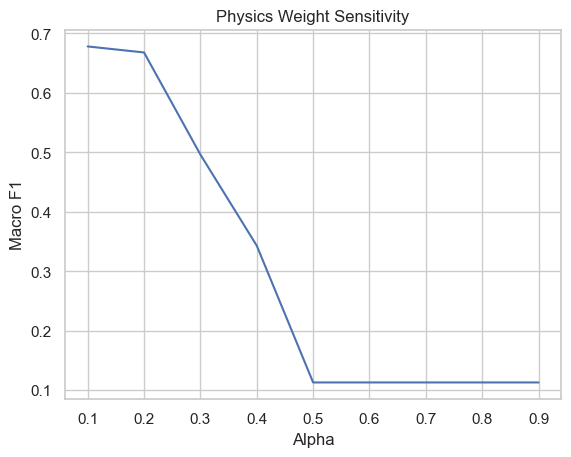

In [ ]:
alphas = np.linspace(0.1, 0.9, 9)
f1_list = []

for a in alphas:
    probs = ensemble.predict_proba(X_r_test)
    probs = apply_physics_soft_fusion(X_r_test, probs, alpha=a)
    preds = np.argmax(probs, axis=1)
    f1 = f1_score(y_test_enc, preds, average="macro")
    f1_list.append(f1)

plt.plot(alphas, f1_list)
plt.xlabel("Alpha")
plt.ylabel("Macro F1")
plt.title("Physics Weight Sensitivity")
plt.show()

# 12. Stability Testing & Best Model Selection

Running **10 iterations** to find the best performing Hybrid Ensemble model and save it as `master_ensemble.pkl`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("="*80)
print("STABILITY TESTING & BEST MODEL SELECTION")
print("="*80)
print()

# Initialize tracking
results_columns = ['Run', 'Random_State', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']

# Dynamically get class names from LabelEncoder
if 'le' in locals():
    class_names_stability = list(le.classes_)
else:
    # Fallback if le not defined (should not happen if previous cells run)
    class_names_stability = ['Harsh_Brake', 'Harsh_Cornering', 'Normal_Driving', 'Sharp_Turn',
                             'Sudden_Acceleration', 'Sudden_Lane_Change']

print(f"Target Classes ({len(class_names_stability)}): {class_names_stability}")

for class_name in class_names_stability:
    results_columns.extend([f'{class_name}_Precision', f'{class_name}_Recall', f'{class_name}_F1'])

results_df = pd.DataFrame(columns=results_columns)

# Track best model
best_f1 = 0
best_model = None
best_run_info = {}

print(f"Initialized results storage with {len(results_columns)} metrics")
print(f"Starting 10-iteration training loop...\n")
print("-"*80)

STABILITY TESTING & BEST MODEL SELECTION

Target Classes (5): ['Harsh_Brake', 'Normal_Driving', 'Sharp_Turn', 'Sudden_Acceleration', 'Sudden_Lane_Change']
Initialized results storage with 20 metrics
Starting 10-iteration training loop...

--------------------------------------------------------------------------------


In [ ]:
NUM_RUNS = 10
base_random_state = 42

for run_num in range(1, NUM_RUNS + 1):
    print(f"\n{'='*80}")
    print(f"RUN {run_num}/{NUM_RUNS}")
    print(f"{'='*80}")
    
    current_random_state = base_random_state + (run_num - 1) * 10
    np.random.seed(current_random_state)
    print(f"Random State: {current_random_state}")
    
    # Create ensemble
    ensemble_stability = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=4,
                random_state=current_random_state, class_weight='balanced'
            )),
            ('xgb', XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.1,
                random_state=current_random_state, colsample_bytree=0.8,
                min_child_weight=3, reg_alpha=0.5, reg_lambda=0.5,
                objective='multi:softprob', eval_metric='mlogloss'
            )),
            ('lgbm', LGBMClassifier(
                n_estimators=300, max_depth=5, num_leaves=20,
                min_child_samples=50, random_state=current_random_state,
                class_weight='balanced', reg_alpha=0.5, reg_lambda=0.5,
                importance_type='gain'
            ))
        ],
        voting='soft',
        weights=np.array([2., 1., 1.])
    )
    
    # Train
    print("Training model...")
    ensemble_stability.fit(X_train_bal, y_train_bal)
    
    # Predict
    print("Making predictions...")
    y_pred = ensemble_stability.predict(X_r_test)
    
    # Get metrics - handling potential class mismatches safely
    # We let sklearn determine the classes present in y_pred
    report_dict = classification_report(
        y_test_enc,
        y_pred,
        output_dict=True,
        zero_division=0
    )
    
    macro_precision = report_dict['macro avg']['precision']
    macro_recall = report_dict['macro avg']['recall']
    macro_f1 = report_dict['macro avg']['f1-score']
    
    print(f"\nMacro Metrics: P={macro_precision:.4f} | R={macro_recall:.4f} | F1={macro_f1:.4f}")
    
    # Check if this is the best model
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_model = ensemble_stability
        best_run_info = {
            'run': run_num,
            'random_state': current_random_state,
            'precision': macro_precision,
            'recall': macro_recall,
            'f1': macro_f1
        }
        print(f">>> NEW BEST MODEL! F1={macro_f1:.4f} <<<")
    
    # Store results
    result_row = {
        'Run': run_num, 'Random_State': current_random_state,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1
    }
    
    # Add per-class metrics safely
    # report_dict might use numeric keys '0', '1' etc. or class names depending on sklearn version/usage
    for idx, class_name in enumerate(class_names_stability):
        # Try multiple key formats: class name, integer index, string index
        if class_name in report_dict:
            key = class_name
        elif str(idx) in report_dict:
            key = str(idx)
        elif idx in report_dict:
            key = idx
        else:
            key = None
            
        if key is not None:
            result_row[f'{class_name}_Precision'] = report_dict[key]['precision']
            result_row[f'{class_name}_Recall'] = report_dict[key]['recall']
            result_row[f'{class_name}_F1'] = report_dict[key]['f1-score']
        else:
            # Class was not predicted in this run
            result_row[f'{class_name}_Precision'] = 0.0
            result_row[f'{class_name}_Recall'] = 0.0
            result_row[f'{class_name}_F1'] = 0.0
    
    results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)

print(f"\n{'='*80}")
print(f"ALL {NUM_RUNS} RUNS COMPLETED")
print(f"{'='*80}")
if best_run_info:
    print(f"\nBEST MODEL: Run {best_run_info['run']} (Random State {best_run_info['random_state']})")
    print(f"  Precision: {best_run_info['precision']:.4f}")
    print(f"  Recall:    {best_run_info['recall']:.4f}")
    print(f"  F1-Score:  {best_run_info['f1']:.4f}")
else:
    print("\nNo best model found (check data/training)")


RUN 1/10
Random State: 42
Training model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027884 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53550
[LightGBM] [Info] Number of data points in the train set: 65446, number of used features: 210
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19828\1840060005.py:104: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53550
[LightGBM] [Info] Number of data points in the train set: 65446, number of used features: 210
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
# Statistical Analysis
print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

if not results_df.empty:
    macro_stats = {
        'Precision': {'Mean': results_df['Macro_Precision'].mean(), 'Std': results_df['Macro_Precision'].std()},
        'Recall': {'Mean': results_df['Macro_Recall'].mean(), 'Std': results_df['Macro_Recall'].std()},
        'F1-Score': {'Mean': results_df['Macro_F1'].mean(), 'Std': results_df['Macro_F1'].std()}
    }

    for metric, stats in macro_stats.items():
        print(f"\n{metric}: {stats['Mean']:.4f} ± {stats['Std']:.4f}")

    std_f1 = macro_stats['F1-Score']['Std']
    stability = "EXCELLENT" if std_f1 < 0.01 else "GOOD" if std_f1 < 0.02 else "MODERATE" if std_f1 < 0.03 else "HIGH VARIANCE"
    print(f"\nStability: {stability} (std dev = {std_f1:.4f})")

    # Display results table
    print("\n" + "="*80)
    print("RESULTS TABLE")
    print("="*80 + "\n")
    display(results_df[['Run', 'Random_State', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']])


STATISTICAL ANALYSIS

Precision: 0.8165 ± 0.0065

Recall: 0.6757 ± 0.0056

F1-Score: 0.7224 ± 0.0050

Stability: EXCELLENT (std dev = 0.0050)

RESULTS TABLE



,Run,Random_State,Macro_Precision,Macro_Recall,Macro_F1
0,1,42,0.820417,0.669135,0.717531
1,2,52,0.822134,0.671979,0.720312
2,3,62,0.801603,0.674284,0.717862
3,4,72,0.820892,0.684190,0.728614
4,5,82,0.816062,0.682486,0.728109
5,6,92,0.818051,0.678729,0.725355
6,7,102,0.818813,0.672431,0.721616
7,8,112,0.808395,0.667568,0.713851
8,9,122,0.819462,0.679812,0.727055
9,10,132,0.818905,0.676486,0.723561



Results saved to: Results_19_01_2026\stability_test_results.csv


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19828\2632626460.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([results_df['Macro_Precision'], results_df['Macro_Recall'], results_df['Macro_F1']],


Visualization saved to: Results_19_01_2026\stability_visualization.png


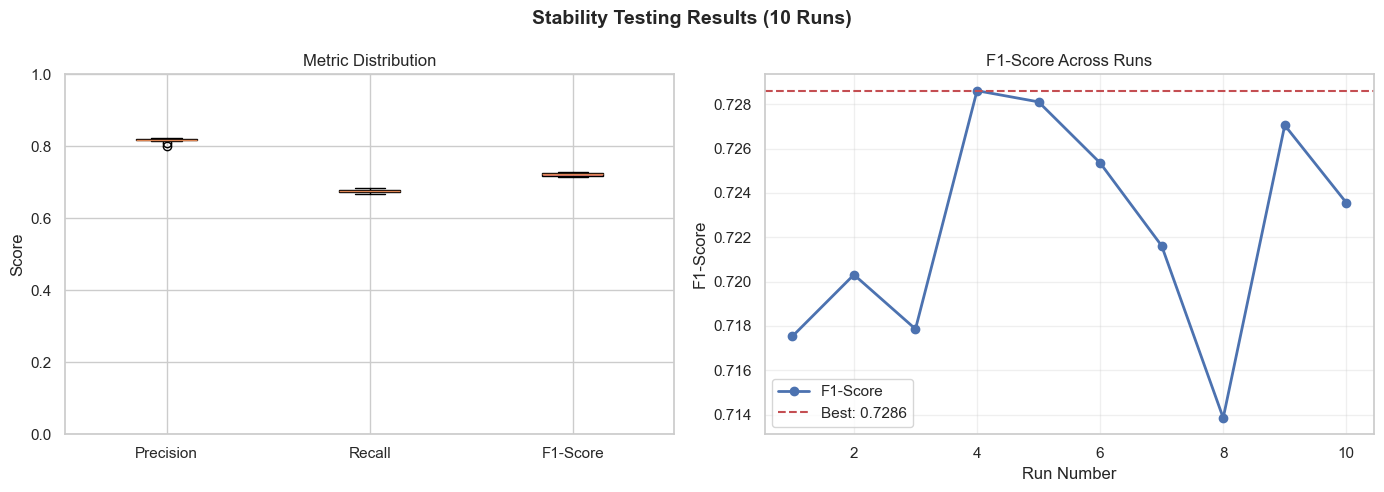

In [ ]:
# Save Results and Visualization
import os
import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

output_file = os.path.join(OUTPUT_DIR, 'stability_test_results.csv')
results_df.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")

# Visualization
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Stability Testing Results (10 Runs)', fontsize=14, fontweight='bold')

    # Box plot
    ax1 = axes[0]
    bp = ax1.boxplot([results_df['Macro_Precision'], results_df['Macro_Recall'], results_df['Macro_F1']],
                      labels=['Precision', 'Recall', 'F1-Score'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
        patch.set_facecolor(color)
    ax1.set_ylabel('Score')
    ax1.set_title('Metric Distribution')
    ax1.set_ylim([0, 1])

    # Line plot
    ax2 = axes[1]
    ax2.plot(results_df['Run'], results_df['Macro_F1'], marker='o', linewidth=2, label='F1-Score')
    ax2.axhline(y=best_f1, color='r', linestyle='--', label=f'Best: {best_f1:.4f}')
    ax2.set_xlabel('Run Number')
    ax2.set_ylabel('F1-Score')
    ax2.set_title('F1-Score Across Runs')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    viz_file = os.path.join(OUTPUT_DIR, 'stability_visualization.png')
    plt.savefig(viz_file, dpi=300, bbox_inches='tight')
    print(f"Visualization saved to: {viz_file}")
    plt.show()

## Save Best Model as Master Ensemble

In [ ]:
print("\n" + "="*80)
print("SAVING BEST MODEL AS MASTER ENSEMBLE")
print("="*80)

if best_model is not None:
    # Save the best ensemble model
    ensemble = best_model  # This is now the BEST model from 10 runs!

    joblib.dump(ensemble, os.path.join(OUTPUT_DIR, "master_ensemble.pkl"))
    joblib.dump(le, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))

    print(f"\nSaved BEST model from Run {best_run_info['run']}:")
    print(f"  File: {os.path.join(OUTPUT_DIR, 'master_ensemble.pkl')}")
    print(f"  Performance: F1={best_run_info['f1']:.4f}")

    # Export to ONNX
    try:
        if hasattr(ensemble, 'named_estimators_'):
            fitted_rf = ensemble.named_estimators_['rf']
        else:
            fitted_rf = ensemble.estimators_[0]

        model_to_export = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
        model_to_export.fit(X_train_bal.iloc[:100], y_train_bal[:100])
        
        if hasattr(fitted_rf, 'estimators_'):
            model_to_export.estimators_ = fitted_rf.estimators_
            model_to_export.n_outputs_ = fitted_rf.n_outputs_
            model_to_export.n_classes_ = fitted_rf.n_classes_
            model_to_export.classes_ = fitted_rf.classes_
            if hasattr(fitted_rf, 'n_features_in_'):
                model_to_export.n_features_in_ = fitted_rf.n_features_in_
                
        initial_type = [('float_input', FloatTensorType([None, 30]))]
        options = {type(model_to_export): {'zipmap': False}}
        
        onx = convert_sklearn(model_to_export, initial_types=initial_type, 
                             target_opset=12, options=options)
        
        onnx_path = os.path.join(OUTPUT_DIR, "master_ensemble.onnx")
        with open(onnx_path, "wb") as f:
            f.write(onx.SerializeToString())
        
        print(f"\nONNX export successful: {onnx_path}")

    except Exception as e:
        print(f"\nONNX export failed: {e}")
else:
    print("\nNo best model to save!")

print("\n" + "="*80)
print("COMPLETE! Ready for deployment.")
print("="*80)


SAVING BEST MODEL AS MASTER ENSEMBLE

Saved BEST model from Run 4:
  File: Results_19_01_2026\master_ensemble.pkl
  Performance: F1=0.7286

ONNX export successful: Results_19_01_2026\master_ensemble.onnx

COMPLETE! Ready for deployment.



Generating Confusion Matrix...


<Figure size 1000x800 with 0 Axes>

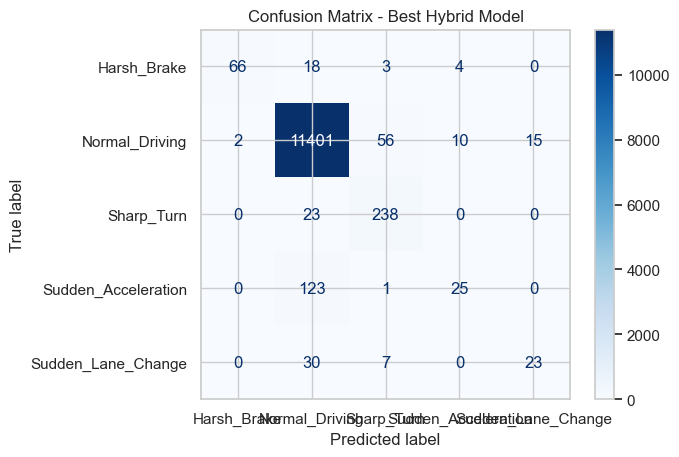

Generating ROC Curves...


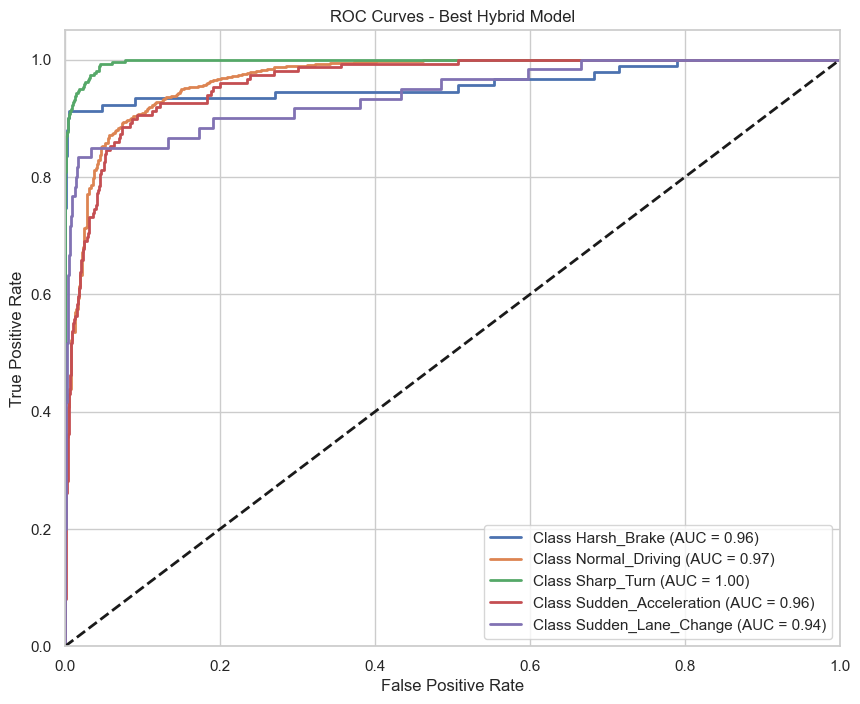

Generating Calibration Curves...


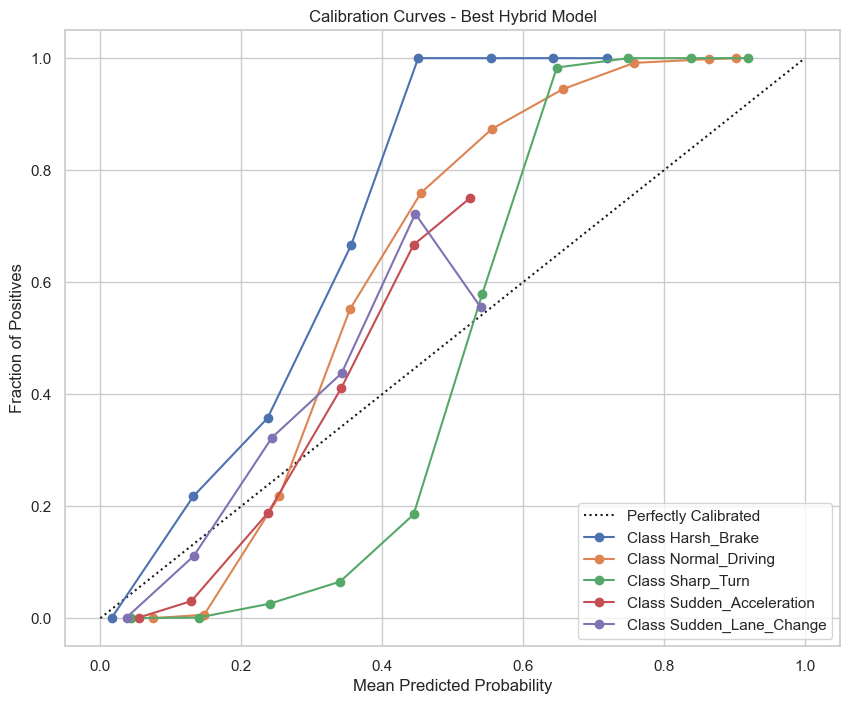


Archiving Artifacts...
Moved original_class_distribution.png -> Results_08_02_2026/

All reports and models saved to: c:\Users\VICTUS\Documents\reserch\New folder\22\2\2026\Results_08_02_2026


: 

In [ ]:
# === COMPREHENSIVE FINAL EVALUATION & REPORTING ===
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# --- NameError Fix ---
# Ensure best_hybrid_model is defined using the 'ensemble' variable from the previous cell
if 'best_hybrid_model' not in locals() and 'ensemble' in locals():
    best_hybrid_model = ensemble
    print(f"Using 'ensemble' as 'best_hybrid_model'")
elif 'best_hybrid_model' not in locals():
    raise NameError("Could not find 'best_hybrid_model' or 'ensemble'. Please run the Stability Testing cell first.")
# ---------------------

# 1. Create Results Directory
RESULTS_DIR = 'Results_08_02_2026'
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    print(f'Created results directory: {RESULTS_DIR}')

# 2. Confusion Matrix for Best Model
print('\nGenerating Confusion Matrix...')
y_pred_final = best_hybrid_model.predict(X_r_test)
cm = confusion_matrix(y_test_enc, y_pred_final)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_stability)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Best Hybrid Model')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_best_model.png'))
plt.show()

# 3. ROC Curves (One-vs-Rest)
print('Generating ROC Curves...')
y_test_bin = label_binarize(y_test_enc, classes=np.unique(y_test_enc))
n_classes = y_test_bin.shape[1]
y_score = best_hybrid_model.predict_proba(X_r_test)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names_stability[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Best Hybrid Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves_best_model.png'))
plt.show()

# 4. Calibration / Reliability Curves
print('Generating Calibration Curves...')
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')

for i in range(n_classes):
    prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_score[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Class {class_names_stability[i]}')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves - Best Hybrid Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(RESULTS_DIR, 'calibration_curve_best_model.png'))
plt.show()

# 5. Move Artifacts to Results Folder
artifacts_to_move = [
    'stability_test_visualization.png',
    'original_class_distribution.png',
    'master_ensemble.pkl',
    'label_encoder.pkl',
    'stability_test_results.csv'
]

print('\nArchiving Artifacts...')
for artifact in artifacts_to_move:
    if os.path.exists(artifact):
        shutil.move(artifact, os.path.join(RESULTS_DIR, artifact))
        print(f'Moved {artifact} -> {RESULTS_DIR}/')

print(f'\nAll reports and models saved to: {os.path.abspath(RESULTS_DIR)}')

In [26]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.9 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.5 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.5 MB 2.0 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 1.8 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.8 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.7 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.5 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.7 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.5 MB 1.6 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.5 MB 1.6 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/9.5 MB 1.4 MB/s eta 0:00:05
   -------------- --------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
